In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../Veriler/08-email_classification_svm.csv")
print(
    df.info(),
    df.describe(),
    df.head()
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
None        subject_formality_score  sender_relationship_score   email_type
count              1000.000000                1000.000000  1000.000000
mean                 -1.009046                  -0.006300     0.498000
std                   0.654219                   1.059501     0.500246
min                  -3.532770                  -2.218219     0.000000
25%                  -1.252867                  -1.006076     0.000000
50%                  -0.994760                   0.439233     0.000000
75%                  -0.754839                   0.994943     

In [3]:
# binary classification olduğunu kanıtlamış oluyoruz.
df['email_type'].unique()

array([0, 1])

<Axes: xlabel='subject_formality_score', ylabel='sender_relationship_score'>

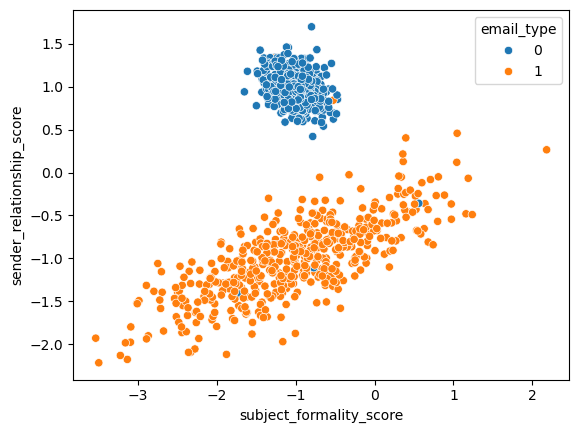

In [4]:
sns.scatterplot(x=df['subject_formality_score'], y=df['sender_relationship_score'],hue=df['email_type'])

In [5]:
x = df[['subject_formality_score','sender_relationship_score']].values
y = df['email_type'].values

In [6]:
# Train-Test split etmek için sklearn kütüphanesindeki fonksiyonu kullanıyoruz.
from sklearn.model_selection import train_test_split

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42)

In [8]:
y_test

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0])

In [9]:
x_train = torch.tensor (x_train,  dtype=torch.float32)
x_test  = torch.tensor (x_test ,  dtype=torch.float32)

y_train = torch.tensor (y_train,  dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor (y_test,   dtype=torch.float32).unsqueeze(1)

In [10]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
# y kısmında bir boyut hatası var bunu düzeltmemiz lazım. bunun için unsqueeze ekliyoruz.

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [11]:
y_train.ndim

2

In [12]:
from torch import nn

In [13]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x)) 

In [14]:
model = ClassificationModel()

In [15]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.01)

In [16]:
def calculate_accuracy(y_test,y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [17]:
y_logits = model(x_test)[:5]

In [18]:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4540],
        [0.5822],
        [0.4781],
        [0.5313],
        [0.4557]], grad_fn=<SigmoidBackward0>)

In [19]:
y_preds = torch.round(y_pred_probs)

In [20]:
y_preds

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]], grad_fn=<RoundBackward0>)

In [21]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [22]:
torch.manual_seed(42)
epochs = 200

for epoch in range(epochs):
    model.train()
    y_logits = model(x_train)
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = calculate_accuracy(y_train,y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_logits = model(x_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test=y_test,y_pred=test_pred)

        if epoch % 5 == 0:
            print(f"Epoch {epoch}, Loss: {loss}, Accuracy: {acc}, Test Loss:{test_loss}, Test Acc: {test_acc}")

Epoch 0, Loss: 0.61787348985672, Accuracy: 90.25, Test Loss:0.6095148324966431, Test Acc: 93.0
Epoch 5, Loss: 0.6007398962974548, Accuracy: 92.5, Test Loss:0.5927863121032715, Test Acc: 94.5
Epoch 10, Loss: 0.584503173828125, Accuracy: 93.875, Test Loss:0.5769320130348206, Test Acc: 96.0
Epoch 15, Loss: 0.5690740346908569, Accuracy: 95.5, Test Loss:0.5618627667427063, Test Acc: 96.0
Epoch 20, Loss: 0.5543736815452576, Accuracy: 96.125, Test Loss:0.5474997758865356, Test Acc: 96.0
Epoch 25, Loss: 0.5403326749801636, Accuracy: 96.75, Test Loss:0.5337734222412109, Test Acc: 96.5
Epoch 30, Loss: 0.5268899202346802, Accuracy: 97.25, Test Loss:0.5206229090690613, Test Acc: 96.5
Epoch 35, Loss: 0.5139912962913513, Accuracy: 97.75, Test Loss:0.507994532585144, Test Acc: 97.0
Epoch 40, Loss: 0.5015894174575806, Accuracy: 98.25, Test Loss:0.49584126472473145, Test Acc: 97.0
Epoch 45, Loss: 0.4896424412727356, Accuracy: 98.375, Test Loss:0.48412176966667175, Test Acc: 97.0
Epoch 50, Loss: 0.47811

In [23]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

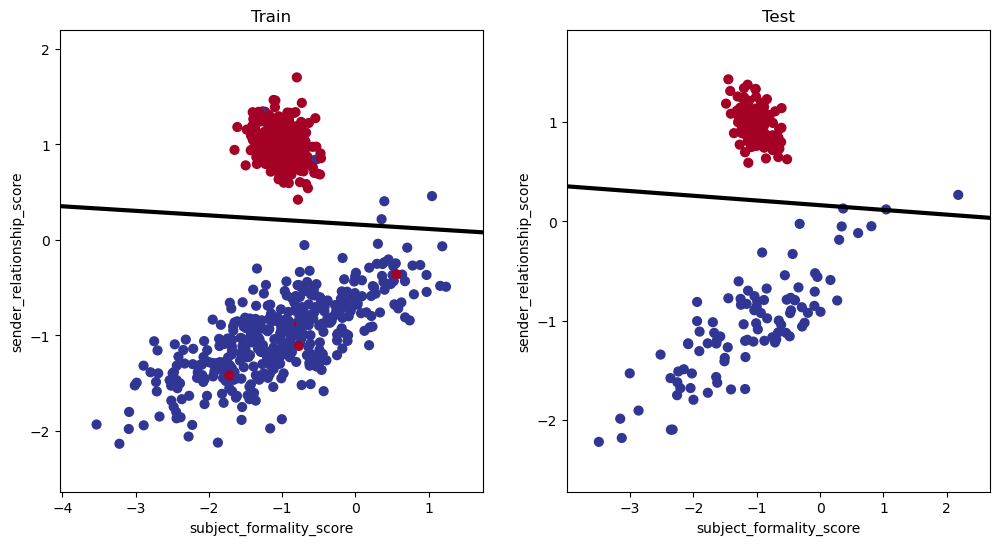

In [24]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model, x_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model, x_test, y_test)

plt.show()